In [118]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from glob import glob
from Charts.ploTools import *
from Charts.resumeTools import *

In [119]:
FOLDER_EXP = 'OptimizeIterationsResults/OptunaDDPGExpBase_T*'
METRICS_EXP = '/00000*/*/metrics_resume_testing.pkl'

In [120]:
folder_list = glob(FOLDER_EXP+METRICS_EXP)
folder_list
metrics_resume_testing_avg_last = last_data_list(folder_list)

In [93]:
#Para NetWorth

In [121]:
def getNetWorthMetExp1(resume_last_metrics):
    finalDict = {}
    for agent in resume_last_metrics:
        finalDict[agent] = resume_last_metrics[agent]['net_worths_delta_acum']
    return finalDict

In [122]:
networthLastExp1Dict = getNetWorthMetExp1(metrics_resume_testing_avg_last)

In [123]:
df = pd.DataFrame(networthLastExp1Dict)

In [124]:
dfTras = df.T
dfTras['valueList'] = dfTras.values.tolist()
# reset index
dfTras.reset_index(inplace=True)
dfTras = dfTras[['index', 'valueList']]
dfTras.columns = ['key', 'NetWorth']
dfTras['mean'] = dfTras.NetWorth.apply(lambda x: np.mean(x))
dfTras['std'] = dfTras.NetWorth.apply(lambda x: np.std(x))
from scipy.stats import ttest_ind
dfTras.sort_values(by='mean', ascending=True, inplace=True)

,key,NetWorth
0,DDPG Agent,"[112933.599162264, 90866.15500873412, 87807.27..."
1,Random Agent,"[82854.40005365861, 86649.86507854675, 90548.9..."
2,SP500 Agent,"[100937.29773233645, 100937.29773233645, 10093..."


In [128]:
def checkMeanGreaterTTest(metricA, metricB, df):
    metricAData = df[df['key'] == metricA]['NetWorth'].values[0]
    metricBData = df[df['key'] == metricB]['NetWorth'].values[0]

    # Perform t-test
    if np.mean(metricAData) > np.mean(metricBData):
        alternative_to_use = 'greater'
    else:
        alternative_to_use = 'less'
    t_stat, p_value = ttest_ind(metricAData, metricBData, alternative=alternative_to_use)
    result = 0
    if p_value < 0.05: # significance level
        result = 1
    return result

def tTestMeanGreaterTTest(metricA, metricB, df):
    metricAData = df[df['key'] == metricA]['NetWorth'].values[0]
    metricBData = df[df['key'] == metricB]['NetWorth'].values[0]

    # Perform t-test
    if np.mean(metricAData) > np.mean(metricBData):
        alternative_to_use = 'greater'
    else:
        alternative_to_use = 'less'
    t_stat, p_value = ttest_ind(metricAData, metricBData, alternative=alternative_to_use)
    return p_value

In [143]:
ExperimentList = dfTras.key.to_list()
ExperimentList.pop(1)

'SP500 Agent'

In [144]:
ExperimentList

['Random Agent', 'DDPG Agent']

In [145]:
# Improve the create_p_value_matrix function to return a DataFrame with the experiment names as both rows and columns
def create_flag_p_value_matrix(df, experimentList):
    num_experiments = len(experimentList)
    p_value_matrix = np.zeros((num_experiments, num_experiments))

    for i in range(num_experiments):
        for j in range(num_experiments):
            if i != j:
                exp1Name = experimentList[i]
                exp2Name = experimentList[j]
                p_value_matrix[i, j] = checkMeanGreaterTTest(exp1Name, exp2Name, df)

    return pd.DataFrame(p_value_matrix, index=experimentList, columns=experimentList)

def create_p_value_matrix(df, experimentList):
    num_experiments = len(experimentList)
    p_value_matrix = np.zeros((num_experiments, num_experiments))

    for i in range(num_experiments):
        for j in range(num_experiments):
            if i != j:
                exp1Name = experimentList[i]
                exp2Name = experimentList[j]
                p_value_matrix[i, j] = tTestMeanGreaterTTest(exp1Name, exp2Name, df)

    return pd.DataFrame(p_value_matrix, index=experimentList, columns=experimentList)

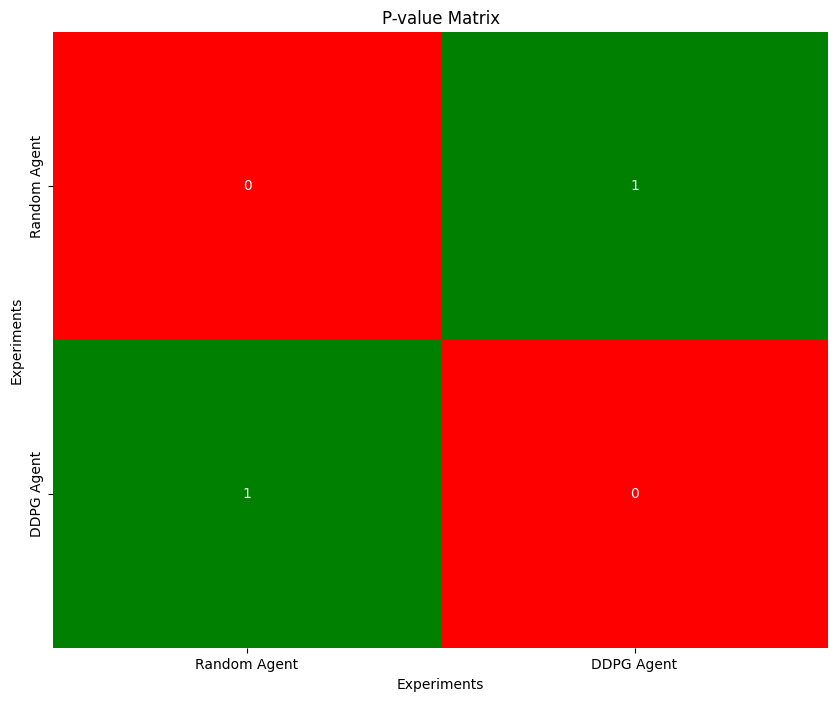

In [146]:
#improve the appearance of the matrix put the 1s in green and the 0 in red
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib as mpl

def plot_flag_p_value_matrix(p_value_matrix):
    # Create a custom colormap
    cmap = mcolors.ListedColormap(['red', 'green'])
    bounds = [0, 0.5, 1]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # Create the heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(p_value_matrix, annot=True, fmt=".0f", cmap=cmap, norm=norm, cbar=False,
                xticklabels=p_value_matrix.columns, yticklabels=p_value_matrix.index)
    plt.title('P-value Matrix')
    plt.xlabel('Experiments')
    plt.ylabel('Experiments')
    plt.show()

# Create the p-value matrix
p_value_matrix = create_flag_p_value_matrix(dfTras, ExperimentList)
# Plot the p-value matrix
plot_flag_p_value_matrix(p_value_matrix)

In [147]:
p_value_matrix

,Random Agent,DDPG Agent
Random Agent,0.0,1.0
DDPG Agent,1.0,0.0


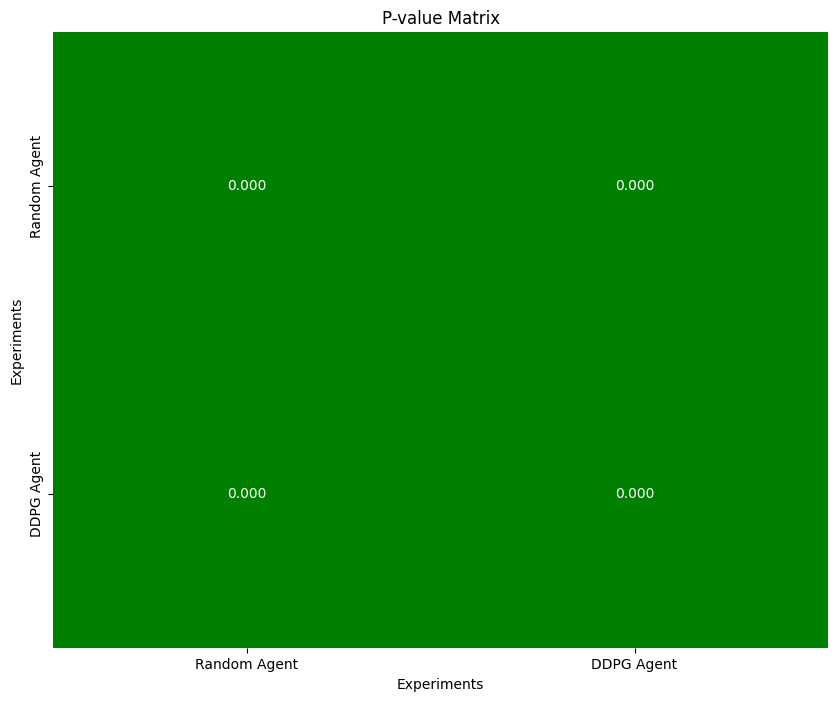

In [148]:
create_p_value_matrix(dfTras, ExperimentList)
#improve the appearance of the p values matrix with a color scale , but when the p value is less than 0.05 put the color in green and when the p value is grater than 0.05 use a scale of yellow to red
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib as mpl

def plot_p_value_matrix(p_value_matrix):
    # Create a custom colormap
    cmap = mcolors.ListedColormap(['green', 'yellow', 'red'])
    bounds = [0, 0.05, 0.1, 1]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # Create the heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(p_value_matrix, annot=True, fmt=".3f", cmap=cmap, norm=norm, cbar=False,
                xticklabels=p_value_matrix.columns, yticklabels=p_value_matrix.index)
    plt.title('P-value Matrix')
    plt.xlabel('Experiments')
    plt.ylabel('Experiments')
    plt.show()
# Create the p-value matrix

p_value_matrix = create_p_value_matrix(dfTras, ExperimentList)
# Plot the p-value matrix
plot_p_value_matrix(p_value_matrix)


In [149]:
create_p_value_matrix(dfTras, ExperimentList)

,Random Agent,DDPG Agent
Random Agent,0.000000e+00,2.771820e-17
DDPG Agent,2.771820e-17,0.000000e+00


In [151]:
# Just leave the mean , std, confidence_interval and key columns in the dataframe
dfTras = dfTras[['key', 'mean', 'std']]
dfTras

,key,mean,std
1,Random Agent,88027.352624,5322.428606
2,SP500 Agent,100937.297732,0.000000
0,DDPG Agent,102749.467008,15029.617936


# Para el Ratio Sharpe

In [152]:
FOLDER_EXP = 'OptimizeIterationsResults/OptunaDDPGExpBase_T*'
METRICS_EXP = '/00000*/*/metrics_resume_testing.pkl'

In [153]:
folder_list = glob(FOLDER_EXP+METRICS_EXP)

In [155]:
metrics_resume_testing_avg = mean_resume_data(folder_list)

In [156]:
metrics_resume_testing_avg

{'DDPG Agent': {'net_worths_delta': [1475.9795036995033,
   -1051.0349013879,
   -1279.7719375059833,
   2191.981680932903,
   -284.1384734103993,
   -681.881862296288,
   -506.9923729434944,
   -872.3106271438976,
   -186.69960614439114,
   -743.0841999919919,
   749.8969828640144,
   1225.9140513236116,
   393.97648880220294,
   5772.208712061072,
   -36.37694778559642,
   -586.0441958051964,
   -1091.2121818833848,
   222.22832019510753,
   1277.0205744338173,
   -170.7186627388971,
   555.6877417930012,
   -3789.7239621937993,
   -62.43421624249793,
   -403.4563731458264,
   -544.567151355378,
   -903.120800396615,
   652.3938575892264,
   9.53203406020766,
   1268.2057859602762,
   -8590.548791057572,
   5069.375647694321,
   -1176.6821755767546,
   3017.0040212219055,
   1136.7494165596945,
   -1574.9071403096889,
   441.06489062971264,
   -353.9416285445006,
   -279.3478729675933,
   -730.5664535053958,
   -704.6354979774966,
   -528.5466344712033,
   470.4065838385079,
   3449.

In [157]:
def getRSharpeExp1(resume_metrics):
    finalDict = {}
    for agent in resume_metrics:
        finalDict[agent] = resume_metrics[agent]['sharpe_ratios']
    return finalDict

In [158]:
RsharpeLastExp1Dict = getRSharpeExp1(metrics_resume_testing_avg)

In [159]:
RsharpeLastExp1Dict

{'DDPG Agent': [10.95671633772094,
  -3.989270509154818,
  -6.68958107361982,
  7.9057527813813575,
  -0.5378831877664708,
  -4.425210030513095,
  -2.084030557762863,
  -2.6465191561704215,
  -1.9886898286762618,
  -4.084600436958589,
  3.276713504875762,
  2.334772428464827,
  3.1475175944049014,
  14.966050290918346,
  -0.8555282620163807,
  -2.9450419613265733,
  -3.04886162738996,
  1.2733728378820237,
  6.190177149086329,
  -0.807653764790986,
  4.652912131108913,
  -11.16252827250757,
  -0.9623844782777486,
  -1.9865971142787877,
  -2.62146468064808,
  -4.2945086596992645,
  2.065038665318722,
  1.1182450697181148,
  3.122943691648239,
  -7.256095841862297,
  11.454496231671396,
  -4.39644830756106,
  7.8930629758853526,
  3.791654582843729,
  -4.438174853864968,
  0.9243471084253685,
  -0.4427975001514604,
  -0.4430883930286431,
  -2.9408221871673543,
  -3.266287878007789,
  -0.8079949308758191,
  1.0382477048442953,
  6.425358180226783,
  2.2557791717556763,
  0.448078962721231

In [160]:
df = pd.DataFrame(RsharpeLastExp1Dict)

In [161]:
dfTras = df.T
dfTras['valueList'] = dfTras.values.tolist()
# reset index
dfTras.reset_index(inplace=True)
dfTras = dfTras[['index', 'valueList']]
dfTras.columns = ['key', 'NetWorth']
dfTras['mean'] = dfTras.NetWorth.apply(lambda x: np.mean(x))
dfTras['std'] = dfTras.NetWorth.apply(lambda x: np.std(x))
from scipy.stats import ttest_ind
dfTras.sort_values(by='mean', ascending=True, inplace=True)

In [167]:
dfTras

,key,NetWorth,mean,std
1,Random Agent,"[11.497408304718904, -9.262807371574986, -8.67...",-1.478424,7.769213
0,DDPG Agent,"[10.95671633772094, -3.989270509154818, -6.689...",0.254661,4.863861
2,SP500 Agent,"[16.913844930888686, -9.056702014573235, -7.64...",0.982667,8.638923


In [168]:
ExperimentList = dfTras.key.to_list()
ExperimentList.pop(2)

'SP500 Agent'

In [169]:
ExperimentList

['Random Agent', 'DDPG Agent']

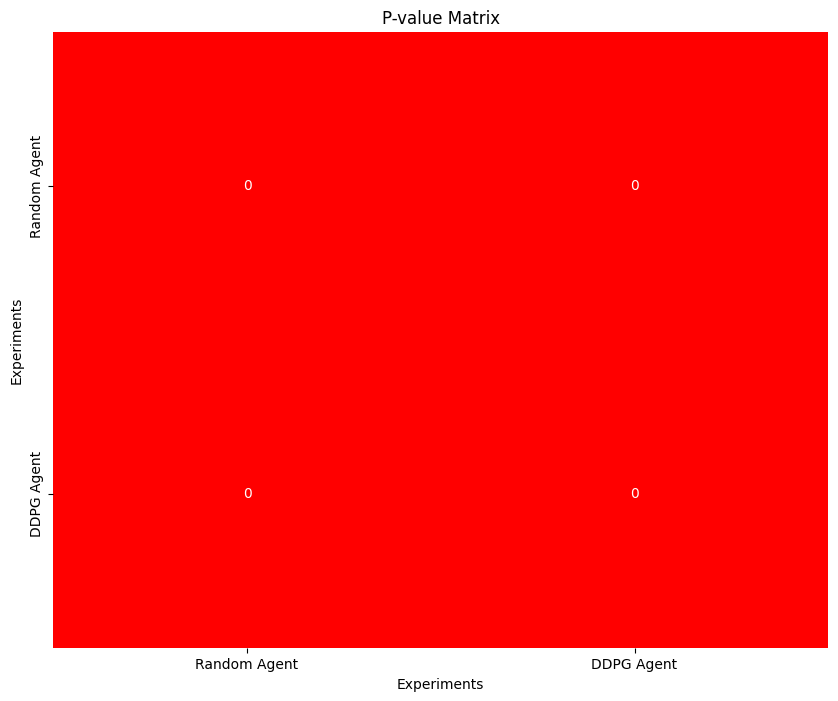

In [170]:
# Create the p-value matrix
p_value_matrix = create_flag_p_value_matrix(dfTras, ExperimentList)
# Plot the p-value matrix
plot_flag_p_value_matrix(p_value_matrix)

In [171]:
create_p_value_matrix(dfTras, ExperimentList)

,Random Agent,DDPG Agent
Random Agent,0.00000,0.09437
DDPG Agent,0.09437,0.00000


In [172]:
1-0.09437

0.90563